In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.isnull().sum())

(200, 5)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


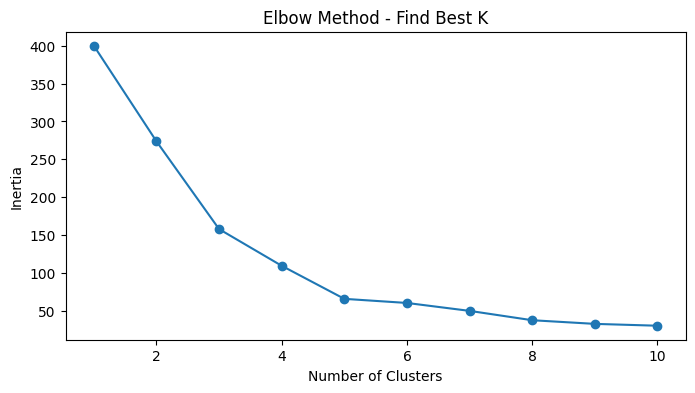

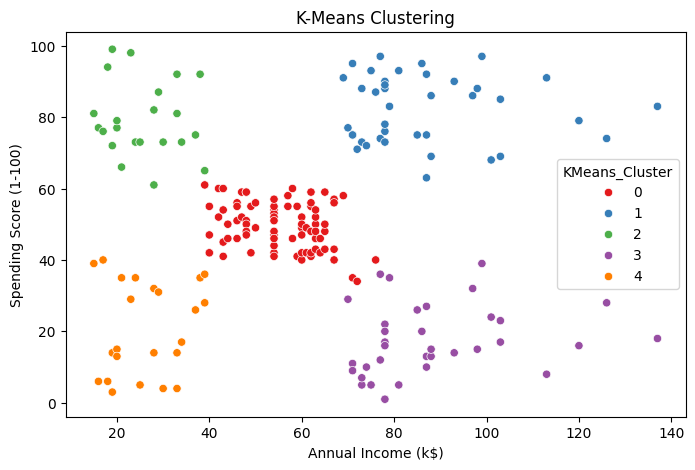

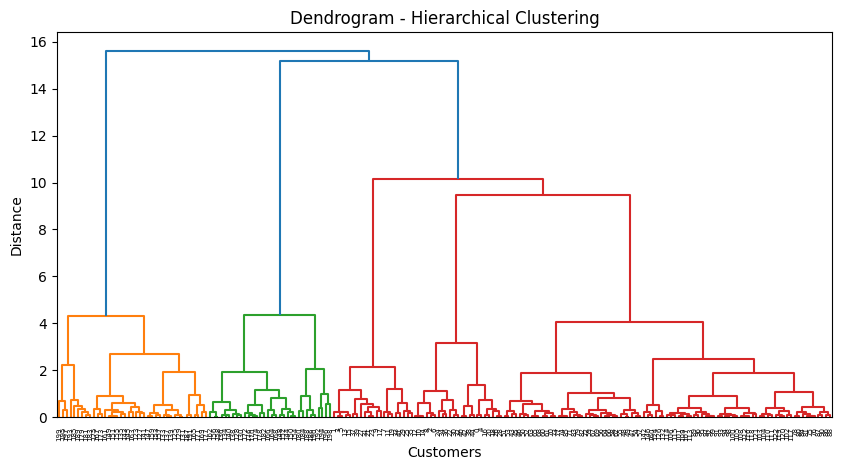

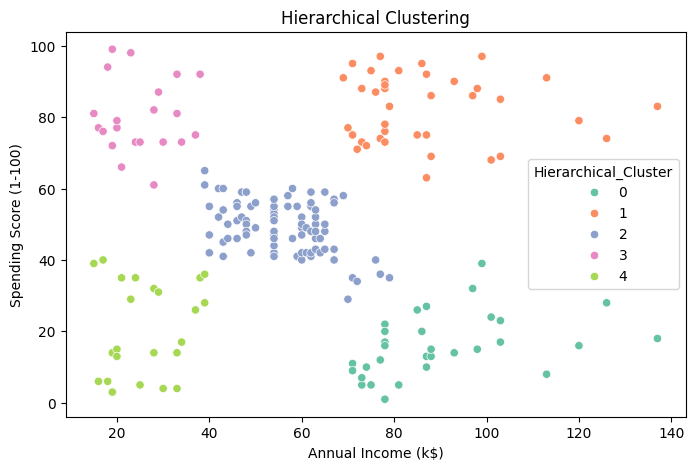

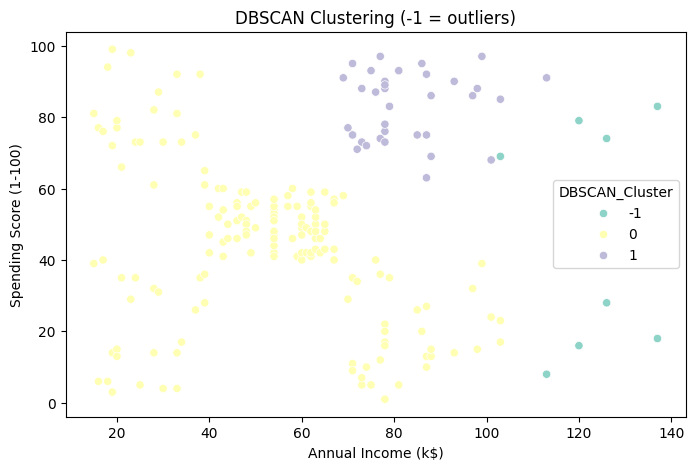

DBSCAN Clusters found: [ 0  1 -1]
Outliers (-1): 8


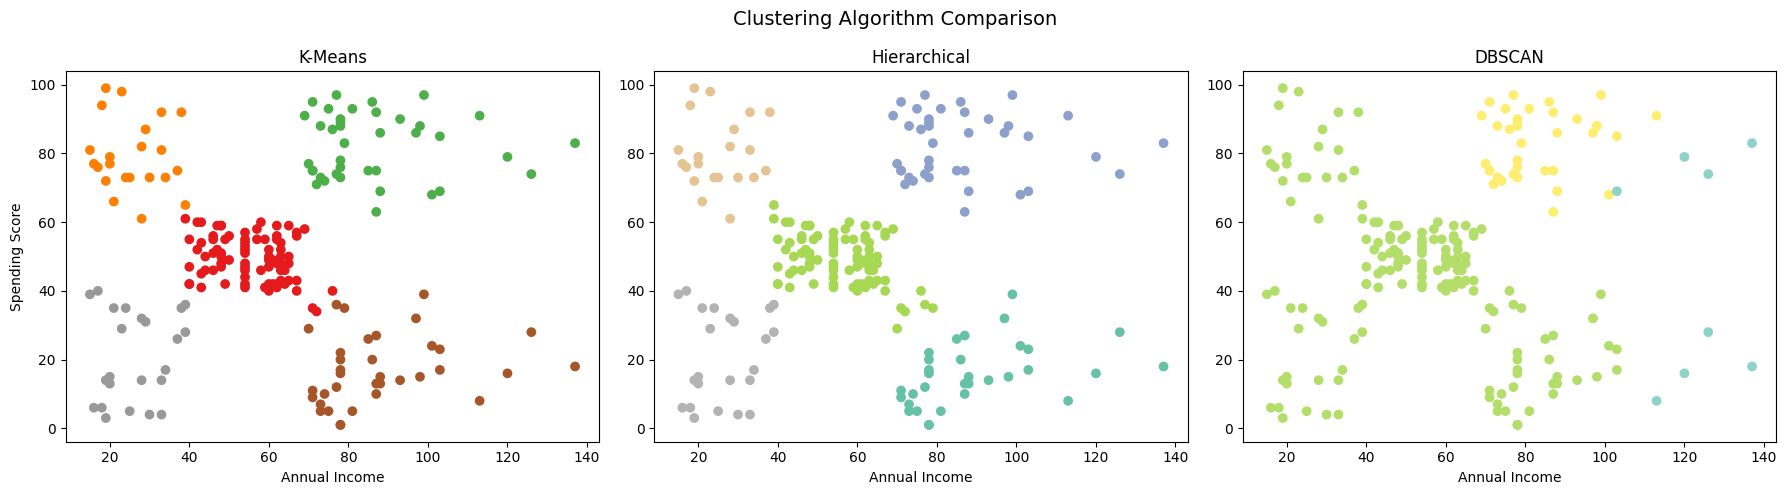

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

# Load data
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data — important for clustering!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# MODEL 1 — K-MEANS
# ============================================
# Elbow method to find best K
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Train K-Means with best K (5 based on elbow)
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize K-Means clusters
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)',
                hue='KMeans_Cluster',
                palette='Set1',
                data=df)
plt.title('K-Means Clustering')
plt.show()

# ============================================
# MODEL 2 — HIERARCHICAL (Agglomerative)
# ============================================
# Dendrogram to find best number of clusters
plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

# Train Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
df['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='Hierarchical_Cluster',
                palette='Set2',
                data=df)
plt.title('Hierarchical Clustering')
plt.show()

# ============================================
# MODEL 3 — DBSCAN
# ============================================
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='DBSCAN_Cluster',
                palette='Set3',
                data=df)
plt.title('DBSCAN Clustering (-1 = outliers)')
plt.show()

# How many clusters did DBSCAN find?
print("DBSCAN Clusters found:", df['DBSCAN_Cluster'].unique())
print("Outliers (-1):", (df['DBSCAN_Cluster'] == -1).sum())

# ============================================
# COMPARE ALL MODELS
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# K-Means
axes[0].scatter(X['Annual Income (k$)'], 
                X['Spending Score (1-100)'],
                c=df['KMeans_Cluster'], cmap='Set1')
axes[0].set_title('K-Means')
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Spending Score')

# Hierarchical
axes[1].scatter(X['Annual Income (k$)'],
                X['Spending Score (1-100)'],
                c=df['Hierarchical_Cluster'], cmap='Set2')
axes[1].set_title('Hierarchical')
axes[1].set_xlabel('Annual Income')

# DBSCAN
axes[2].scatter(X['Annual Income (k$)'],
                X['Spending Score (1-100)'],
                c=df['DBSCAN_Cluster'], cmap='Set3')
axes[2].set_title('DBSCAN')
axes[2].set_xlabel('Annual Income')

plt.suptitle('Clustering Algorithm Comparison', fontsize=14)
plt.tight_layout()
plt.show()